# iTransformer — CATSA Train → EmpaticaE4 Test ( only)

**Model**: iTransformer (Inverted Transformer)
- Temp는 단변량(1채널) 신호: 채널 1개가 단일 토큰이 되며, 240차원 시계열 전체를 임베딩 차원으로 투영
- Transformer 위에 MLP 분류 헤드 적용

**학습**: CATSA 전체 피험자 (Temp 1채널, 4Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

TASKS        = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
TEMP_FS       = 4

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/Temp/Save_model_iTransformer")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── CATSA Utilities ───────────────────────────────────────────────────────
def discover_subjects(root: Path) -> List[str]:
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "TEMP.csv").exists() for t in TASKS):
            out.append(d.name)
    return out

def read_temp(path: Path) -> np.ndarray:
    df   = pd.read_csv(path)
    nc   = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    vals = df[nc[0]].to_numpy(np.float32) if nc else pd.to_numeric(df.iloc[:,0], errors='coerce').to_numpy(np.float32)
    return vals[~np.isnan(vals)]

def make_windows_1d(sig: np.ndarray, W: int, S: int) -> np.ndarray:
    if len(sig) < W: return np.empty((0, 1, W), np.float32)
    return np.asarray([sig[i:i+W] for i in range(0, len(sig)-W+1, S)], np.float32)[:, None, :]

def build_catsa_arrays(subjects: List[str], W: int, S: int) -> Tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []
    for sub in subjects:
        path  = CATSA_ROOT / sub
        all_v = np.concatenate([read_temp(path / t / "TEMP.csv") for t in TASKS])
        mu    = float(np.mean(all_v))
        sigma = float(np.std(all_v)) + 1e-8
        for task in TASKS:
            norm = (read_temp(path / task / "TEMP.csv") - mu) / sigma
            w    = make_windows_1d(norm, W, S)
            if len(w): xs.append(w); ys.append(np.full(len(w), int(task in STRESS_TASKS), np.int64))
    return np.concatenate(xs), np.concatenate(ys)

# ── EmpaticaE4 Utilities ──────────────────────────────────────────────────
def build_e4_labels(n: int, fs: int = 4) -> Tuple[np.ndarray, int]:
    fixed_s = {"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
               "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    task4_s = max(0, n // fs - sum(fixed_s.values()))
    segs = [("rest0",180,0),("task1",600,1),("rest1",120,-1),("task2",300,1),
            ("rest2",120,-1),("task3",180,1),("rest3",120,-1),("task4",task4_s,1),
            ("rest4",120,-1),("task5",60,1),("rest5",120,-1)]
    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        end = min(cur + dur_s * fs, n)
        if end > cur: labels[cur:end] = lab
        cur = end
        if cur >= n: break
    return labels, int(task4_s)

def e4_windows(temp: np.ndarray, labels: np.ndarray, W: int, S: int) -> Tuple[np.ndarray, np.ndarray]:
    mask  = labels >= 0
    mu    = float(np.mean(temp[mask])) if mask.any() else float(np.mean(temp))
    sigma = (float(np.std(temp[mask])) + 1e-8) if mask.any() else (float(np.std(temp)) + 1e-8)
    norm  = ((temp - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i+W])
        if len(u) == 1 and u[0] in (0, 1): xs.append(norm[i:i+W]); ys.append(int(u[0]))
    if not xs: return np.empty((0,1,W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32)[:, None, :], np.asarray(ys, np.int64)

# ── Training Utilities ────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__(); self.gamma, self.alpha = gamma, alpha
    def forward(self, logits, y):
        y = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        pt  = torch.sigmoid(logits)*y + (1-torch.sigmoid(logits))*(1-y)
        fl  = (1-pt).pow(self.gamma)*bce
        if self.alpha is not None: fl = (self.alpha*y+(1-self.alpha)*(1-y))*fl
        return fl.mean()

def make_loader(x, y, bs, shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
                      batch_size=bs, shuffle=shuffle)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); tot=n=tp=tn=fp=fn=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); lg=model(xb)
        tot+=criterion(lg,yb).item()*len(xb); n+=len(xb)
        pred=(torch.sigmoid(lg)>=0.5).long(); yi=yb.long()
        tp+=int(((pred==1)&(yi==1)).sum()); tn+=int(((pred==0)&(yi==0)).sum())
        fp+=int(((pred==1)&(yi==0)).sum()); fn+=int(((pred==0)&(yi==1)).sum())
    acc=(tp+tn)/max(n,1); pre=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":2*pre*rec/max(pre+rec,1e-8),
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch(model, loader, optimizer, criterion):
    model.train(); tot=n=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss=criterion(model(xb),yb); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        tot+=loss.item()*len(xb); n+=len(xb)
    return tot/max(n,1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [13]:
# ── iTransformer Model (Temp — univariate) ─────────────────────────────────
class iTransformerClassifier(nn.Module):
    """
    iTransformer for univariate TEMP.
    The single TEMP channel is the only 'variate token'.
    Its full 240-sample time series is linearly projected to d_model.
    A 2-layer Transformer encoder is applied (self-attention on 1 token
    becomes a weighted identity, so the value comes from the FFN sublayer).
    """
    def __init__(self, seq_len: int = 240, n_vars: int = 1, d_model: int = 128,
                 n_heads: int = 8, n_layers: int = 3, d_ff: int = 256, dropout: float = 0.1):
        super().__init__()
        self.var_embed = nn.Linear(seq_len, d_model)
        self.norm_in   = nn.LayerNorm(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, 240]
        tokens = self.norm_in(self.var_embed(x))  # [B, 1, d_model]
        out    = self.transformer(tokens)          # [B, 1, d_model]
        out    = out.mean(dim=1)                   # [B, d_model]
        return self.head(out).squeeze(-1)          # [B]

model_test = iTransformerClassifier()
print(f"Input: {torch.randn(4,1,240).shape}  Output: {model_test(torch.randn(4,1,240)).shape}")
print(f"Trainable params: {sum(p.numel() for p in model_test.parameters() if p.requires_grad):,}")
del model_test

Input: torch.Size([4, 1, 240])  Output: torch.Size([4])
Trainable params: 437,121


In [14]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"       : 42,
    "val_ratio"  : 0.10,
    "window_size": TEMP_FS * 60,   # 240
    "stride"     : TEMP_FS * 10,   # 40
    "batch_size" : 64,
    "epochs"     : 50,
    "lr"         : 1e-3,
    "wd"         : 1e-4,
    "patience"   : 8,
    "d_model"    : 128,
    "n_heads"    : 8,
    "n_layers"   : 3,
    "d_ff"       : 256,
    "dropout"    : 0.1,
}

np.random.seed(HP["seed"]); torch.manual_seed(HP["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(HP["seed"])

subjects  = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng       = np.random.default_rng(HP["seed"])
idx       = rng.permutation(len(subjects))
n_val     = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs  = [subjects[i] for i in sorted(idx[:n_val])]
train_subs= [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} | Val: {len(val_subs)}")

W, S = HP["window_size"], HP["stride"]
print("Building training arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S)
x_val,   y_val   = build_catsa_arrays(val_subs,   W, S)
print(f"Train: {x_train.shape}  Val: {x_val.shape}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val,   y_val,   HP["batch_size"], False)

pos       = float(y_train.sum())
alpha     = float((len(y_train)-pos)/len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)

model = iTransformerClassifier(
    seq_len=W, n_vars=1,
    d_model=HP["d_model"], n_heads=HP["n_heads"],
    n_layers=HP["n_layers"], d_ff=HP["d_ff"], dropout=HP["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=HP["lr"], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=4)

best_val_loss=float("inf"); best_state=None; wait=0; history=[]

for epoch in range(1, HP["epochs"]+1):
    tr_loss = train_epoch(model, loader_tr, optimizer, criterion)
    val_m   = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])
    history.append({"epoch":epoch,"train_loss":tr_loss,"val_loss":val_m["loss"],"val_f1":val_m["f1"]})
    if val_m["loss"] < best_val_loss:
        best_val_loss=val_m["loss"]; best_epoch=epoch; wait=0
        best_state=deepcopy(model.state_dict())
        torch.save({"model_state_dict":best_state,"hp":HP,"epoch":epoch}, SAVE_DIR/"best_model.pt")
    else:
        wait+=1
        if wait>=HP["patience"]: print(f"Early stopping at epoch {epoch} (best: {best_epoch})"); break
    if epoch%5==0 or epoch==1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  f1={val_m['f1']:.4f}")

model.load_state_dict(best_state)
print(f"\nDone. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 | Val: 5
Building training arrays...
Train: (2925, 1, 240)  Val: (325, 1, 240)
[  1] train=0.0579  val=0.0530  f1=0.8761
[  5] train=0.0534  val=0.0600  f1=0.2500
[ 10] train=0.0528  val=0.0527  f1=0.9102
[ 15] train=0.0468  val=0.0395  f1=0.5928
[ 20] train=0.0411  val=0.0353  f1=0.9145
[ 25] train=0.0395  val=0.0298  f1=0.9252
[ 30] train=0.0369  val=0.0276  f1=0.9439
[ 35] train=0.0374  val=0.0263  f1=0.9639
[ 40] train=0.0360  val=0.0280  f1=0.9480
Early stopping at epoch 43 (best: 35)

Done. Best epoch: 35, best_val_loss: 0.0263


In [15]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    temp = read_temp(E4_ROOT / sub / "TEMP.csv")
    labels, task4_sec = build_e4_labels(len(temp))
    x, y_true = e4_windows(temp, labels, W, S)
    if len(x) == 0:
        rows.append({"subject":sub,"n_windows":0,"accuracy":float("nan"),
                     "f1":float("nan"),"precision":float("nan"),"recall":float("nan")})
        continue
    with torch.no_grad():
        logits = model(torch.from_numpy(x).to(DEVICE))
        y_pred = (torch.sigmoid(logits)>=0.5).cpu().numpy().astype(int)
    rows.append({
        "subject":sub,"task4_sec":task4_sec,"n_windows":len(y_true),
        "accuracy":float(accuracy_score(y_true,y_pred)),
        "f1":float(f1_score(y_true,y_pred,zero_division=0)),
        "precision":float(precision_score(y_true,y_pred,zero_division=0)),
        "recall":float(recall_score(y_true,y_pred,zero_division=0)),
    })
    all_true.extend(y_true.tolist()); all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ==="); display(result_df)

if all_true:
    ov_acc=accuracy_score(all_true,all_pred); ov_f1=f1_score(all_true,all_pred,zero_division=0)
    ov_prec=precision_score(all_true,all_pred,zero_division=0); ov_rec=recall_score(all_true,all_pred,zero_division=0)
    print(f"\n=== Overall ===\nAccuracy:{ov_acc:.4f}  F1:{ov_f1:.4f}  Precision:{ov_prec:.4f}  Recall:{ov_rec:.4f}")
    cm = confusion_matrix(all_true, all_pred); print("\nCM:", cm)
    print(classification_report(all_true,all_pred,target_names=["Non-stress","Stress"],zero_division=0))

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,583,159,0.786164,0.879433,0.911765,0.849315
1,subject_02,436,144,0.909722,0.952727,0.909722,1.000000
2,subject_03,156,116,0.758621,0.862745,0.871287,0.854369
3,subject_04,188,119,0.848739,0.918182,0.885965,0.952830
4,subject_05,164,117,0.905983,0.944724,0.989474,0.903846
5,subject_06,244,125,0.760000,0.846939,0.988095,0.741071



=== Overall ===
Accuracy:0.8282  F1:0.9026  Precision:0.9214  Recall:0.8846

CM: [[ 25  53]
 [ 81 621]]
              precision    recall  f1-score   support

  Non-stress       0.24      0.32      0.27        78
      Stress       0.92      0.88      0.90       702

    accuracy                           0.83       780
   macro avg       0.58      0.60      0.59       780
weighted avg       0.85      0.83      0.84       780



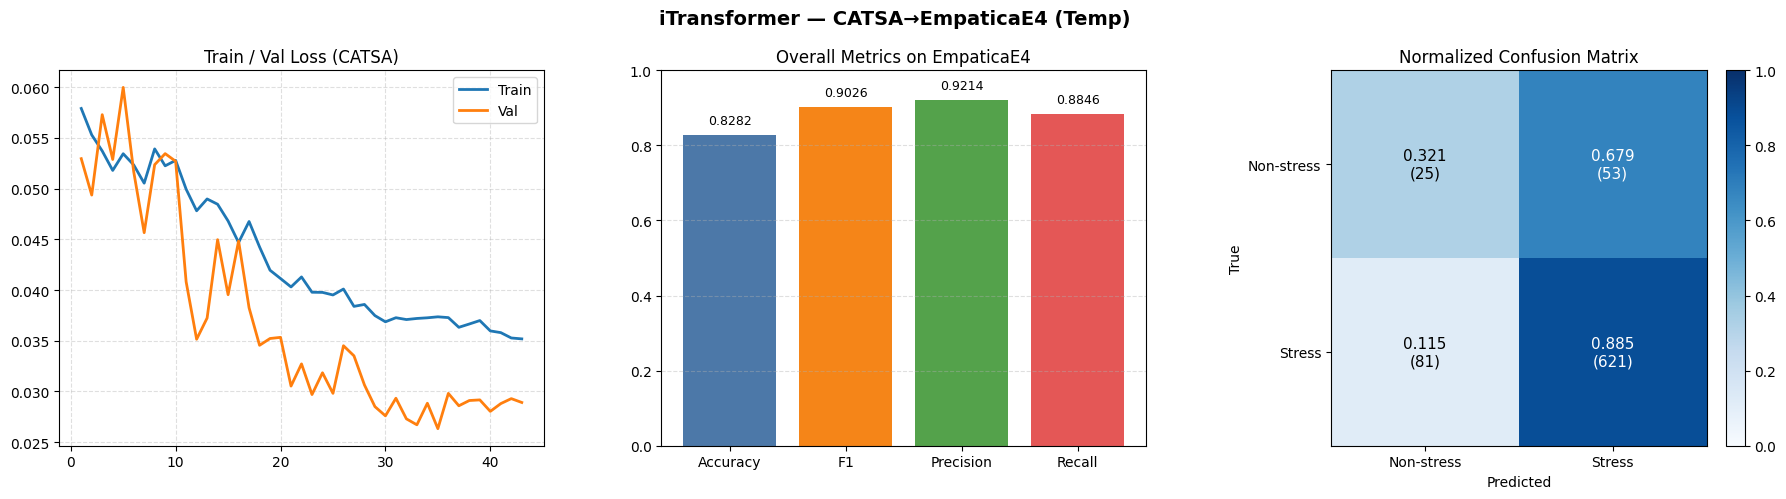

Saved results.png


In [16]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot([h["epoch"] for h in history],[h["train_loss"] for h in history],label="Train",linewidth=2)
axes[0].plot([h["epoch"] for h in history],[h["val_loss"]   for h in history],label="Val",  linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)"); axes[0].legend(); axes[0].grid(linestyle="--",alpha=0.4)

if all_true:
    bars=axes[1].bar(["Accuracy","F1","Precision","Recall"],[ov_acc,ov_f1,ov_prec,ov_rec],
                     color=["#4C78A8","#F58518","#54A24B","#E45756"])
    axes[1].set_ylim(0,1); axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y",linestyle="--",alpha=0.4)
    for b,v in zip(bars,[ov_acc,ov_f1,ov_prec,ov_rec]):
        axes[1].text(b.get_x()+b.get_width()/2,v+0.02,f"{v:.4f}",ha="center",va="bottom",fontsize=9)

    cm_norm=cm.astype(float)/cm.sum(axis=1,keepdims=True).clip(1)
    im=axes[2].imshow(cm_norm,cmap="Blues",vmin=0,vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"]); axes[2].set_yticklabels(["Non-stress","Stress"])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    thr=cm_norm.max()/2
    for i in range(2):
        for j in range(2):
            axes[2].text(j,i,f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",ha="center",va="center",
                         color="white" if cm_norm[i,j]>thr else "black",fontsize=11)
    fig.colorbar(im,ax=axes[2],fraction=0.046,pad=0.04)

fig.suptitle("iTransformer — CATSA→EmpaticaE4 (Temp)",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR/"results.png",dpi=150,bbox_inches="tight"); plt.show()
print("Saved results.png")